In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / ".git").exists() or (p / "Datasets").exists():
            return p
    raise FileNotFoundError(f"Project root not found from: {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_22 = str(PROJECT_ROOT / "Datasets" / "datasets-session-22")

titanic = pd.read_csv(f"{DATASET_22}/titanic.csv")
expense_data = pd.read_csv(f"{DATASET_22}/expense_data.csv")

In [4]:
import seaborn as sns
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Pivot table

The pivot table takes simple column wise data as input  and groups the entries into a two dimentional table that provides a multidimentional summarization of the data

In [5]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.groupby('sex')[['total_bill']].mean()

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59385/2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [7]:
df.groupby(['sex','smoker'])[['total_bill']].mean()

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59385/1859643203.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean()


total_bill
sex    smoker            
Male   Yes      22.284500
       No       19.791237
Female Yes      17.977879
       No       18.105185

In [9]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59385/3627826641.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [10]:
#nultidimentional

df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc='sum')

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59385/127609111.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc='sum')


size                                                  tip  \
day            Thur          Fri          Sat          Sun          Thur   
time          Lunch Dinner Lunch Dinner Lunch Dinner Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       23      0     5     12     0     71     0     39  30.58   
       No        50      0     0      4     0     85     0    124  58.83   
Female Yes       17      0     6      8     0     33     0     10  20.93   
       No        60      2     3      2     0     30     0     43  58.49   

                      ...               total_bill                        \
day                   ...   Sun               Thur           Fri           
time          Dinner  ... Lunch  Dinner      Lunch Dinner  Lunch  Dinner   
sex    smoker         ...                                                  
Male   Yes       0.0  ...   0.0   52.82     191.71   0.00  34.16  129.46   
       No        0.0  ...   0.0  133.96     369.73   0.00   0.00   34.95   
Female Yes       0.0  ...   0.0   14.00     134.53   0.00  39.78   48.80   
       No        3.0  ...   0.0   46.61     381.58  18.78  15.98   22.75   

                                           
day             Sat           Sun          
time          Lunch  Dinner Lunch  Dinner  
sex    smoker                              
Male   Yes      0.0  589.62   0.0  392.12  
       No       0.0  637.73   0.0  877.34  
Female Yes      0.0  304.00   0.0   66.16  
       No       0.0  247.05   0.0  291.54  

[4 rows x 24 columns]

In [11]:
expense_data.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [13]:
expense_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [15]:
expense_data['Date'] = pd.to_datetime(expense_data['Date'])

In [16]:
expense_data['month']=expense_data['Date'].dt.month

In [17]:
expense_data.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,3
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,3
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,3
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,3
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,3


<Axes: xlabel='month'>

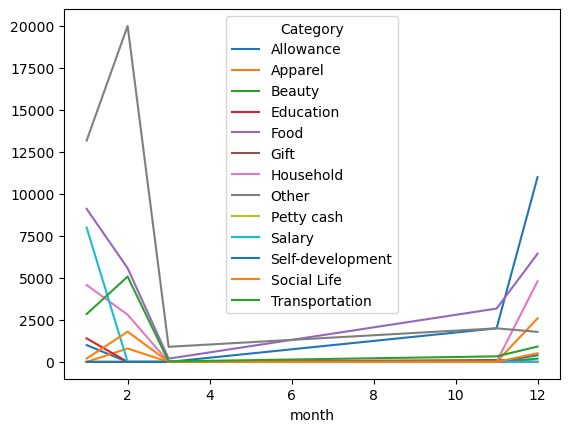

In [22]:
expense_data.pivot_table(index='month', columns='Category', values='INR',aggfunc='sum',fill_value=0).plot()

In [25]:
#pandas String 
s = pd.Series(['cat','car','dog',None])
s.str.startswith('c')

0     True
1     True
2    False
3     None
dtype: object

In [26]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
titanic['Name'].str.upper()

0                                BRAUND, MR. OWEN HARRIS
1      CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...
2                                 HEIKKINEN, MISS. LAINA
3           FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)
4                               ALLEN, MR. WILLIAM HENRY
                             ...                        
886                                MONTVILA, REV. JUOZAS
887                         GRAHAM, MISS. MARGARET EDITH
888             JOHNSTON, MISS. CATHERINE HELEN "CARRIE"
889                                BEHR, MR. KARL HOWELL
890                                  DOOLEY, MR. PATRICK
Name: Name, Length: 891, dtype: object

In [28]:
#DateTime functions using pandas
pd.Timestamp('2023-10-01')

Timestamp('2023-10-01 00:00:00')